In [1]:
%load_ext autoreload
%autoreload 2
# Reloads edited .py modules (online_learning_utils, casual_multioutput_pipeline, ...) before every
# cell, so changes to their source take effect without restarting the kernel.

# Online learning — whole-population ranking (Model 1)

**Policy-guided active learning** variant of the online-enrolment idea (nb 02): instead of
duelling arriving patients two at a time, each round scores **every** not-yet-enrolled
patient with the current model and enrols the top 100 by acquisition score. Enrolled
patients keep their real, historical treatment — no arm allocation: this is randomised-trial
data, so the observed `(T, Y)` is used as-is, exactly like the seed cohort in nb 02.

1. Seed: enrol 1,000 patients at random, fit the causal forest on them.
2. Score every remaining patient: `conflict + c * uncertainty` — the same UCB1-style
   combination as `policy_ucb` in `online_learning_utils.py`, here ranking the whole pool
   instead of a single pair.
3. Enrol the top 100, refit on the enlarged cohort, repeat until the pool is exhausted.
4. After each batch, track the **observed** ischaemic (MI/stroke/death) and bleeding event
   rate among the newly enrolled 100 — expected to drift upward as the most favourable
   patients get taken first and what remains gets progressively more ambiguous/risky.

Treatment coding as in nb 02/06/07/10: `T=1` prolonged, `T=0` shortened;
`CATE_k = risk(prolonged) − risk(shortened)` = benefit of shortening on endpoint `k`.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')                       # silence LGBM feature-name / small-sample notes

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
N = len(T)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


## The online model and the acquisition score

Same light `CausalMultiOutputPipeline` (nb 06) and `conflict`/`uncertainty` scoring as nb 02
(`conflict_from_model`, `uncertainty_from_model`): `conflict` is the bleeding benefit of
shortening plus the weighted ischaemic benefit (z-scored, large-positive = win-win);
`uncertainty` is the same composite built from `predict_cate_std`.

In [3]:
DEFAULT_NUISANCE_PARAMS = {
    "n_estimators": 100,
    "max_depth": 4,
    'min_child_samples': 5,
    "learning_rate": 0.05,
}

# ---------------------------------------------------------------------------
# Base-model flexibility presets
# ---------------------------------------------------------------------------
# Three hand-set configurations that scale the *flexibility* of the whole
# estimator -- both the causal forest itself and its first-stage LGBM nuisances
# -- from strongly regularized to highly flexible. They turn the single
# Optuna-tuned model into an explicit sensitivity analysis: if no CATE
# heterogeneity survives even the flexible model (and the regularized one
# collapses cleanly toward the ATE), the homogeneous-effect conclusion is robust
# to model capacity rather than an artefact of one hyper-parameter choice.
#
# Regularization levers (less flexible <- ... -> more flexible)
#   forest   : max_depth (shallow), min_samples_leaf (large),
#              max_samples (small per-tree subsample), min_balancedness_tol
#              (small -> more balanced splits), min_impurity_decrease (gate
#              against spurious splits).
#   nuisance : max_depth / num_leaves (shallow), min_child_samples (large),
#              n_estimators (few), reg_lambda (stronger L2).
#
# n_estimators are kept divisible by the forest's default subforest_size (4).
CF_MODEL_PRESETS = {
    'regularized': {
        'cf_params': {
            'n_estimators': 400,
            'max_depth': 2,
            'min_samples_leaf': 40,
            'max_samples': 0.30,
            'min_balancedness_tol': 0.30,
        },
        'nuisance_params': {
            'n_estimators': 50,
            'max_depth': 2,
            'num_leaves': 4,
            'min_child_samples': 40,
            'learning_rate': 0.05,
            'reg_lambda': 1.0,
        },
    },
    'medium': {
        'cf_params': {
            'n_estimators': 500,
            'max_depth': 4,
            'min_samples_leaf': 15,
            'max_samples': 0.40,
        },
        'nuisance_params': {
            'n_estimators': 100,
            'max_depth': 4,
            'num_leaves': 15,
            'min_child_samples': 20,
            'learning_rate': 0.05,
        },
    },
    'flexible': {
        'cf_params': {
            'n_estimators': 600,
            'max_depth': 8,
            'min_samples_leaf': 5,
            'max_samples': 0.50,
        },
        'nuisance_params': {
            'n_estimators': 300,
            'max_depth': 8,
            'num_leaves': 63,
            'min_child_samples': 5,
            'learning_rate': 0.03,
        },
    },
}

In [4]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'Meta-learning', 'causal_forest'))
sys.path.insert(0, CF_DIR)
from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import z, fit_cate, conflict_from_model, weighted_isch

ONLINE_TARGETS = list(ENDPOINTS)                            # ['bleed','death','mi','stroke'] -> CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                   # seed tuning targets the bleeding endpoint (nb 06 convention)
ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}    # ischaemic weighting for conflict_from_model

# Light default forest: cheap enough to refit after every batch (same as nb 02).
DEFAULT_CF_PARAMS = {'n_estimators': 600, 'max_depth': 10, 'min_samples_leaf': 10,
                     'max_samples': 0.45, 'inference': True}
DEFAULT_NUISANCE_PARAMS = {'n_estimators': 50, 'max_depth': 6, 'num_leaves': 7,
                           'min_child_samples': 20, 'learning_rate': 0.05}

def uncertainty_from_model(model):
    """Score EVERY patient with the current model and rebuild the uncertainty frame (nb 02)."""
    #X_df = pd.DataFrame(Xn, columns=X.columns)
    cate = model.predict_cate_std(Xn.values)
    df = pd.DataFrame({k: cate[:, ONLINE_TARGETS.index(k)] for k in ENDPOINTS})
    df['uncertainty'] = z(df['bleed']) + weighted_isch({k: z(df[k]) for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
    return df

## Phase 1 — seed

Draw a random seed of 1,000 patients and fit (optionally hyper-tune) the forest on it,
exactly as nb 02's `seed_draw` / `tune_seed` / `seed_fit_tune`. `n_test=0`: this model has
no held-out set, the whole non-seed population is the pool it ranks and enrols from.

In [5]:
def seed_draw(n_seed, seed=0, n_test=0, verbose=True):
    """Draw the arrival order and split it into seed / stream / holdout."""
    rng        = np.random.default_rng(seed)
    order      = rng.permutation(N)
    stream_end = N - n_test
    seed_idx   = list(order[:n_seed])
    test_idx   = list(order[stream_end:])
    if verbose:
        print(f'PHASE 1  seed drawn: {n_seed} patients  |  '
              f'pool: {stream_end - n_seed}  |  held-out: {n_test}')
    return dict(rng=rng, order=order, seed_idx=seed_idx,
                test_idx=test_idx, stream_end=stream_end)


def tune_seed(seed_idx, seed=0, n_trials=0, tune_cv=3):
    """Fit the light default forest on `seed_idx`, then optionally hyper-tune it
    (n_trials=0 skips the search and keeps DEFAULT_CF_PARAMS)."""
    if n_trials:
        from online_learning_utils import tune_on_seed
        cf_params, nuisance_params, study = tune_on_seed(
            seed_idx, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS,
            BLEED_IDX, n_trials=n_trials, cv=tune_cv, seed=seed, optuna_n_jobs=32)
        print(f'         hyper-tuned: best CV score = {study.best_value:+.4f}')
    else:
        cf_params, nuisance_params = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS
    return cf_params, nuisance_params, None


def seed_fit_tune(n_seed, seed=0, n_trials=0, n_test=0, verbose=False):
    """PHASE 1 -- seed, fit, hyper-tune. Returns the prep dict Phase 2 expects."""
    prep = seed_draw(n_seed, seed=seed, n_test=n_test, verbose=verbose)
    cf_params, nuisance_params, _ = tune_seed(prep['seed_idx'], seed=seed, n_trials=n_trials)
    return {**prep, 'cf_params': cf_params, 'nuisance_params': nuisance_params}

## Phase 2 — rank the whole pool, enrol the top 100

`acquisition_score` is `policy_ucb`'s formula (`online_learning_utils.py`) applied to a
whole pool at once instead of a pair: `conflict` (the model's current value estimate) plus
`c * uncertainty` (the exploration bonus, floored at 0). Each round: score every remaining
patient, take the top `batch_size`, enrol them with their real treatment/outcome, refit,
repeat until the pool is empty.

In [6]:
from online_learning_utils import z, fit_cate, conflict_from_model


def acquisition_score(conflict, uncertainty, idx, c=1.0):
    """Exploitation = the model's conflict value estimate (bleeding benefit + weighted
    ischaemic benefit of shortening -- large positive = win-win), z-scored across the scored
    population so it is on the same footing as the uncertainty bonus below. Exploration =
    uncertainty bonus (floored at 0). Same UCB1 combination as `policy_ucb`, with `c` now a
    scale-free exploration weight. Higher = enrol first.

    Previously ranked by angular proximity to the 45-degree line alone (`policy_metric`,
    removed): that ignored magnitude entirely, so a patient with a ~0 CATE on both endpoints
    (angle undefined/noisy right at the origin) could outrank a genuine large win-win patient
    sitting exactly on the diagonal. `conflict['conflict']` already IS the (unnormalised)
    projection of (bleed, ischaemic) onto the 45-degree direction, so using it directly
    rewards alignment with the diagonal *and* distance from the origin in one linear term.
    It needs z-scoring first, though: its raw units (a CATE, std ~0.02) are ~40x smaller
    than `uncertainty`'s z-score sum (std ~1), so without it `c` would need re-calibrating
    from scratch and any old `c` (tuned against the removed angular term, scale ~0-180) would
    make exploration swamp exploitation. At `c=0` (the exploitation-only run below) z-scoring
    is a monotonic rescale and changes nothing -- it only matters once `c>0`.
    """
    idx   = np.asarray(idx)
    value = z(conflict['conflict']).to_numpy()[idx]
    bonus = np.clip(uncertainty['uncertainty'].to_numpy()[idx], 0, None)
    return value + c * bonus

In [7]:
def sample_batch(score, pool, batch_size, temperature=0.0, rng=None):
    """Select `batch_size` patients from `pool` given their `score`.
    temperature=0   -> greedy top-k (same as np.argsort(score)[::-1][:batch_size])
    temperature>0   -> stochastic sampling without replacement, weighted by
                        softmax(score / temperature); higher temperature = more
                        exploration/randomness.

    Implemented via the Gumbel-top-k trick (add i.i.d. Gumbel noise to the logits, then
    take the top n) instead of building `p = softmax(...)` and calling
    `rng.choice(..., p=p)`: that older version renormalised `p` explicitly, and once
    `temperature` decays far enough (it anneals to ~0 by design here) most entries
    underflow to exactly 0.0, leaving fewer non-zero entries than `batch_size` and making
    `rng.choice(replace=False, p=p)` raise `ValueError: Fewer non-zero entries in p than
    size`. Gumbel-top-k samples from the identical Plackett-Luce distribution but only
    ever does an argsort on `logits + noise`, so it never needs to normalise or threshold
    a probability vector and stays exact at any temperature."""
    score = np.asarray(score, dtype=float)
    n = min(batch_size, len(pool))   # non si può campionare più del pool rimanente

    if temperature <= 0:
        order = np.argsort(score)[::-1][:n]
        return [pool[k] for k in order]

    rng = rng or np.random.default_rng()
    logits = score / temperature
    gumbel = -np.log(-np.log(rng.random(len(pool))))   # Gumbel(0,1) noise
    order  = np.argsort(logits + gumbel)[::-1][:n]
    return [pool[k] for k in order]


def run_ranked_enrollment(prep, batch_size=100, c=1.0, refit_trials=0, verbose=True,
                           N_STOP=None, temperature0=0.0, decay_rate=5.0, seed=SEED,
                           autoc_every=None, autoc_cv=3, autoc_target_idx=None,
                           tune_every=None, tune_trials=20):
    """PHASE 2 -- rank every non-enrolled patient each round, enrol the top `batch_size`
    with their real (historical) treatment, refit, repeat until the pool is exhausted.

    `autoc_every`: if set, every time `len(enrolled)` crosses a multiple of it, compute the
    cross-validated AUTOC lower bound (`score_cv_autoc`, same doubly-robust protocol used for
    Optuna tuning elsewhere in the project) on the currently enrolled cohort and store it in
    `hist['autoc_lb']` (NaN on rounds without a checkpoint). This is a ground-truth-outcome,
    out-of-fold read of ranking quality -- unlike the observed batch/cumulative event rates
    above, which are a handful of events per batch of noise. `autoc_target_idx=None` averages
    the lower bound across all four endpoints (bleed/death/mi/stroke); pass `BLEED_IDX` for
    the cheaper, bleed-only version used by the seed tuning.

    `tune_every`: if set, every time `len(enrolled)` crosses a multiple of it, re-tune
    `cf_params`/`nuisance_params` on the currently enrolled cohort via
    `tune_seed(enrolled, seed=seed, n_trials=tune_trials)`, then refit with the new
    hyperparameters. This is cheaper than `refit_trials` (which re-tunes every single round);
    leave `refit_trials=0` when using `tune_every` so the two don't fight each other.
    """
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled = list(prep['seed_idx'])
    pool     = [i for i in range(N) if i not in set(enrolled)]
    rng      = np.random.default_rng(seed)   # per il campionamento stocastico del batch
    next_autoc_at = autoc_every
    next_tune_at  = tune_every

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
    conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)

    if N_STOP is not None:
        if len(enrolled) >= N_STOP:
            print(f"Stopping early: enrolled {len(enrolled)} patients, which is >= N_STOP={N_STOP}.")
            return model, enrolled, pd.DataFrame([])

    hist = []
    while pool:
        if N_STOP is not None:
            if len(enrolled) >= N_STOP:
                print(f"Stopping early: enrolled {len(enrolled)} patients, which is >= N_STOP={N_STOP}.")
                return model, enrolled, pd.DataFrame(hist)

        # annealing lineare: temperatura alta a inizio arruolamento, scende a 0
        # man mano che si arruolano pazienti (frazione di N totali)
        fraction_enrolled = len(enrolled) / N
        temperature = temperature0 * np.exp(-decay_rate * fraction_enrolled)

        score = acquisition_score(conflict, uncertainty, pool, c=c)
        batch = sample_batch(score, pool, batch_size, temperature=temperature, rng=rng)

        enrolled.extend(batch)
        pool = [p for p in pool if p not in set(batch)]

        y_batch    = y.loc[batch]
        y_enrolled = y[y.index.isin(enrolled)]
        y_left_out = y[~y.index.isin(enrolled)]

        def rates(yy):
            isch  = ((yy[ENDPOINTS['death']].to_numpy()  == 1) |
                     (yy[ENDPOINTS['mi']].to_numpy()     == 1) |
                     (yy[ENDPOINTS['stroke']].to_numpy() == 1))
            bleed = yy[ENDPOINTS['bleed']].to_numpy() == 1
            # ritorna anche i conteggi assoluti (non solo i tassi)
            return isch.mean(), bleed.mean(), int(isch.sum()), int(bleed.sum())

        batch_isch,      batch_bleed,      batch_isch_n,      batch_bleed_n      = rates(y_batch)
        cm_isch_no_strt, cm_bleed_no_strt, cm_isch_no_strt_n, cm_bleed_no_strt_n = rates(y_enrolled[~y_enrolled.index.isin(prep['seed_idx'])])
        cm_isch,         cm_bleed,         cm_isch_n,         cm_bleed_n         = rates(y_enrolled)
        leftout_isch,    leftout_bleed,    leftout_isch_n,    leftout_bleed_n    = rates(y_left_out)

        autoc_lb = np.nan
        if autoc_every is not None and len(enrolled) >= next_autoc_at:
            autoc_lb = -model.score_cv_autoc(Xn.values[enrolled], Yv[enrolled], T[enrolled],
                                              cv=autoc_cv, z=1.0, target_idx=autoc_target_idx)
            next_autoc_at += autoc_every
            if verbose:
                print(f"         AUTOC lower bound (cv={autoc_cv}, target_idx={autoc_target_idx}): {autoc_lb:+.4f}")

        hist.append(dict(
            n=len(enrolled),
            batch_n=len(batch),
            temperature=temperature,     # traccia la temperatura usata in questo round
            batch_isch=batch_isch,       batch_bleed=batch_bleed,
            cm_isch=cm_isch,           cm_bleed=cm_bleed,
            cm_isch_no_strt=cm_isch_no_strt, cm_bleed_no_strt=cm_bleed_no_strt,
            leftout_n=len(y_left_out),
            leftout_isch=leftout_isch,   leftout_bleed=leftout_bleed,
            cm_isch_n=cm_isch_n,         cm_bleed_n=cm_bleed_n,
            leftout_isch_n=leftout_isch_n, leftout_bleed_n=leftout_bleed_n,
            autoc_lb=autoc_lb,
        ))

        if verbose:
            print(f"n={len(enrolled):4d} (+{len(batch)})  T={temperature:.3f}  "
                f"batch: isch={batch_isch_n} bleed={batch_bleed_n}  |  "
                f"cm: isch={cm_isch_n} bleed={cm_bleed_n}  |  "
                f"left-out n={len(y_left_out):4d}: isch={leftout_isch_n} bleed={leftout_bleed_n}")

        if refit_trials:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=SEED, n_trials=refit_trials)
        elif tune_every is not None and len(enrolled) >= next_tune_at:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=seed, n_trials=tune_trials)
            next_tune_at += tune_every
            if verbose:
                print(f"         Re-tuned hyperparameters at n={len(enrolled)} (n_trials={tune_trials})")

        model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
        conflict    = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
        uncertainty = uncertainty_from_model(model)

    return model, enrolled, pd.DataFrame(hist)


N_SEED, BATCH_SIZE, N_STOP = 1000, 100, None

prep = seed_fit_tune(N_SEED, seed=SEED, n_trials=10, verbose=True)  # tune on the seed, then pass the prep dict to run_ranked_enrollment
model, enrolled, hist = run_ranked_enrollment(prep, batch_size=BATCH_SIZE, c=0, refit_trials=0, verbose=True,
                                               N_STOP=N_STOP, temperature0=5.0, decay_rate=8.0,
                                               autoc_every=300, tune_every=300, tune_trials=0)

print(f"seed={N_SEED}  final enrolled={len(enrolled)}  batches={len(hist)}")

PHASE 1  seed drawn: 1000 patients  |  pool: 3579  |  held-out: 0
         hyper-tuned: best CV score = -0.0000
         AUTOC lower bound (cv=3, target_idx=None): +0.0000
n=1100 (+100)  T=0.871  batch: isch=4 bleed=12  |  cm: isch=40 bleed=123  |  left-out n=3479: isch=165 bleed=383
         Re-tuned hyperparameters at n=1100 (n_trials=0)
         AUTOC lower bound (cv=3, target_idx=None): -0.0097
n=1200 (+100)  T=0.732  batch: isch=7 bleed=11  |  cm: isch=47 bleed=134  |  left-out n=3379: isch=158 bleed=372
         Re-tuned hyperparameters at n=1200 (n_trials=0)
         AUTOC lower bound (cv=3, target_idx=None): -0.0091
n=1300 (+100)  T=0.614  batch: isch=4 bleed=10  |  cm: isch=51 bleed=144  |  left-out n=3279: isch=154 bleed=362
         Re-tuned hyperparameters at n=1300 (n_trials=0)
         AUTOC lower bound (cv=3, target_idx=None): -0.0081
n=1400 (+100)  T=0.516  batch: isch=4 bleed=14  |  cm: isch=55 bleed=158  |  left-out n=3179: isch=150 bleed=348
         Re-tuned hyperpa

## Results — observed event rate per batch

Ischaemic (MI/stroke/death) and bleeding rate among each newly enrolled batch of 100, in
enrolment order. `n=1,600` and `n=4,000` are marked — the mid/late checkpoints from the
meeting notes' stopping-criterion comparison.

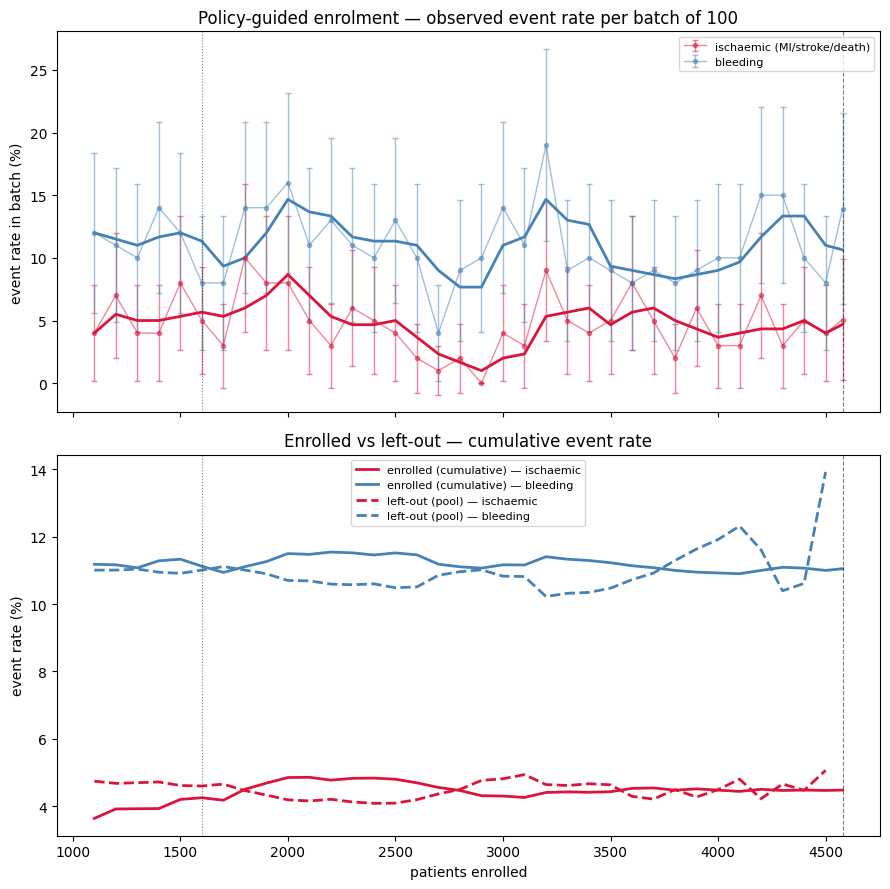

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

n_batch = hist['batch_n'].to_numpy()
isch_p, bleed_p = hist['batch_isch'].to_numpy(), hist['batch_bleed'].to_numpy()
isch_ci  = 1.96 * np.sqrt(isch_p  * (1 - isch_p)  / n_batch)
bleed_ci = 1.96 * np.sqrt(bleed_p * (1 - bleed_p) / n_batch)

# -- top: per-batch event rate (short-term signal, noisy)
ax1.errorbar(hist['n'], isch_p * 100, yerr=isch_ci * 100,
             color='crimson', marker='o', ms=3, lw=1, capsize=2, alpha=.5,
             label='ischaemic (MI/stroke/death)')
ax1.errorbar(hist['n'], bleed_p * 100, yerr=bleed_ci * 100,
             color='steelblue', marker='o', ms=3, lw=1, capsize=2, alpha=.5,
             label='bleeding')

roll = 3
ax1.plot(hist['n'], hist['batch_isch'].rolling(roll, min_periods=1).mean() * 100,
         color='crimson', lw=2)
ax1.plot(hist['n'], hist['batch_bleed'].rolling(roll, min_periods=1).mean() * 100,
         color='steelblue', lw=2)

ax1.set(ylabel='event rate in batch (%)',
        title=f'Policy-guided enrolment — observed event rate per batch of {BATCH_SIZE}')
ax1.legend(fontsize=8)

# -- bottom: cumulative enrolled vs remaining left-out pool
ax2.plot(hist['n'], hist['cm_isch'] * 100, color='crimson', lw=2,
         label='enrolled (cumulative) — ischaemic')
ax2.plot(hist['n'], hist['cm_bleed'] * 100, color='steelblue', lw=2,
         label='enrolled (cumulative) — bleeding')
ax2.plot(hist['n'], hist['leftout_isch'] * 100, color='crimson', lw=2, ls='--',
         label='left-out (pool) — ischaemic')
ax2.plot(hist['n'], hist['leftout_bleed'] * 100, color='steelblue', lw=2, ls='--',
         label='left-out (pool) — bleeding')

ax2.set(xlabel='patients enrolled', ylabel='event rate (%)',
        title='Enrolled vs left-out — cumulative event rate')
ax2.legend(fontsize=8)

for ax in (ax1, ax2):
    ax.axvline(1600, color='k', lw=.8, ls=':', alpha=.5)
    ax.axvline(hist['n'].max(), color='k', lw=.8, ls='--', alpha=.5)

plt.tight_layout()
plt.show()

## Results — AUTOC ranking quality over time

The plots above track **observed** event rates — a handful of events per batch of 100, so
very noisy (see the error bars). This is a different, sturdier question: does the CATE
ranking that `run_ranked_enrollment` is *acting on* actually get better as more patients are
enrolled? `autoc_lb` is the cross-validated AUTOC lower bound (`score_cv_autoc`, the same
doubly-robust protocol used for Optuna tuning, averaged over the four endpoints), evaluated
out-of-fold on the currently enrolled cohort every `autoc_every` patients. Lower bound ~0 =
no significant targeting signal (honest null, same reading as the CausalForest CATE work);
a lower bound that climbs and pulls away from 0 as `n` grows is evidence the ranking is
genuinely improving, not just that the batch composition is drifting.

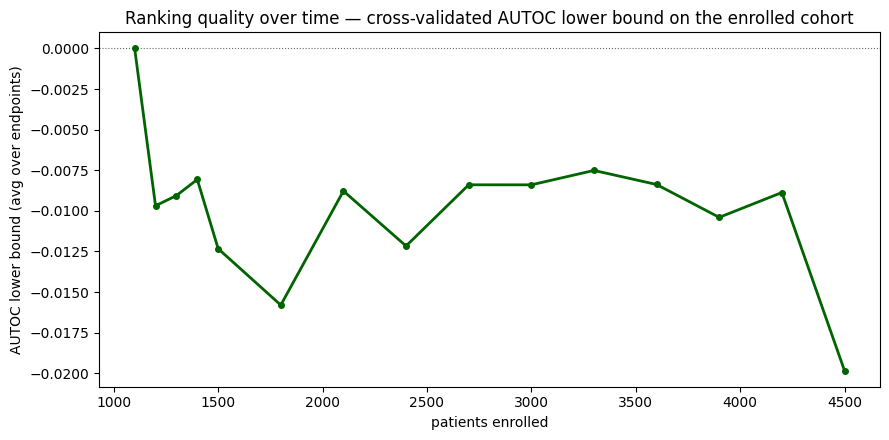

   n  autoc_lb
1100  0.000000
1200 -0.009690
1300 -0.009061
1400 -0.008068
1500 -0.012332
1800 -0.015804
2100 -0.008778
2400 -0.012166
2700 -0.008397
3000 -0.008399
3300 -0.007513
3600 -0.008379
3900 -0.010403
4200 -0.008873
4500 -0.019840


In [9]:
autoc_hist = hist.dropna(subset=['autoc_lb'])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='k', lw=.8, ls=':', alpha=.6)
ax.plot(autoc_hist['n'], autoc_hist['autoc_lb'], color='darkgreen', marker='o', ms=4, lw=2)
ax.set(xlabel='patients enrolled', ylabel='AUTOC lower bound (avg over endpoints)',
       title='Ranking quality over time — cross-validated AUTOC lower bound on the enrolled cohort')
plt.tight_layout()
plt.show()

print(autoc_hist[['n', 'autoc_lb']].to_string(index=False))

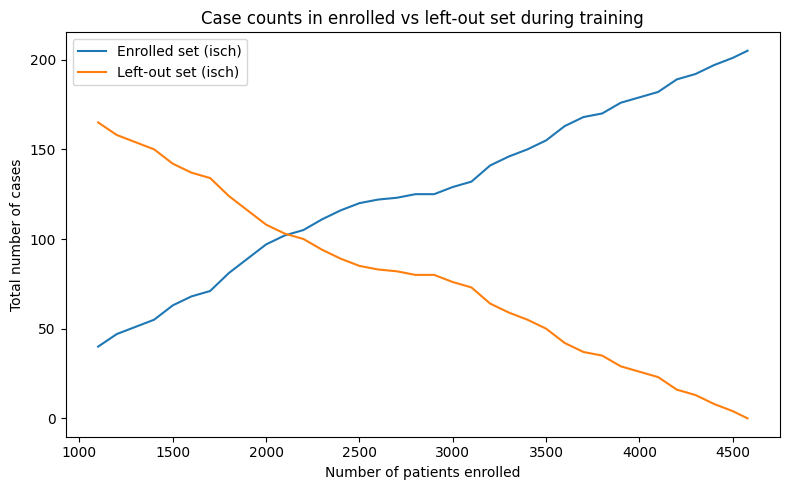

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(hist['n'], hist['cm_isch_n'],
        label='Enrolled set (isch)', color='tab:blue')
ax.plot(hist['n'], hist['leftout_isch_n'],
        label='Left-out set (isch)', color='tab:orange')

ax.set_xlabel('Number of patients enrolled')
ax.set_ylabel('Total number of cases')
ax.set_title('Case counts in enrolled vs left-out set during training')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')  # silence LGBM feature-name / small-sample notes

N_SEED, BATCH_SIZE = 300, 50
N_RUNS  = 10
N_JOBS  = 10
N_STOP = 2200

def _run_once(run):
    prep = seed_fit_tune(N_SEED, seed=SEED + run, n_trials=0, verbose=False)
    _, _, hist = run_ranked_enrollment(prep, batch_size=BATCH_SIZE, c=1.0, refit_trials=0, verbose=False)
    hist['run']  = run
    hist['step'] = np.arange(len(hist))
    return hist

all_hist = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(_run_once)(run) for run in range(N_RUNS)
)
all_hist = pd.concat(all_hist, ignore_index=True)

summary = all_hist.groupby('step').agg(
    n=('n', 'mean'),
    batch_isch_mean=('batch_isch', 'mean'),     batch_isch_std=('batch_isch', 'std'),
    batch_bleed_mean=('batch_bleed', 'mean'),   batch_bleed_std=('batch_bleed', 'std'),
    cum_isch_mean=('cm_isch', 'mean'),         cum_isch_std=('cm_isch', 'std'),
    cum_bleed_mean=('cm_bleed', 'mean'),       cum_bleed_std=('cm_bleed', 'std'),
    leftout_isch_mean=('leftout_isch', 'mean'), leftout_bleed_mean=('leftout_bleed', 'mean'),
).reset_index()

print(summary.to_string())

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


/tmp/ipykernel_3587294/4052524308.py:97: RuntimeWarning: Mean of empty slice.
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3587294/4052524308.py:97: RuntimeWarning: Mean of empty slice.
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3587294/4052524308.py:97: RuntimeWarning: Mean of empty slice.
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3587294/4052524308.py:97: RuntimeWarning: Mean of empty slice.
/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid valu

    step       n  batch_isch_mean  batch_isch_std  batch_bleed_mean  batch_bleed_std  cum_isch_mean  cum_isch_std  cum_bleed_mean  cum_bleed_std  leftout_isch_mean  leftout_bleed_mean
0      0   350.0         0.058000        0.048488          0.104000         0.041952       0.045714      0.016714        0.112000       0.015166           0.044691            0.110381
1      1   400.0         0.044000        0.039777          0.110000         0.038006       0.045500      0.018174        0.111750       0.013073           0.044700            0.110385
2      2   450.0         0.074000        0.051683          0.088000         0.032931       0.048667      0.016412        0.109111       0.012147           0.044345            0.110656
3      3   500.0         0.074000        0.034059          0.126000         0.058916       0.051200      0.016363        0.110800       0.013473           0.043981            0.110468
4      4   550.0         0.070000        0.030185          0.128000         0.04

[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 12.5min finished


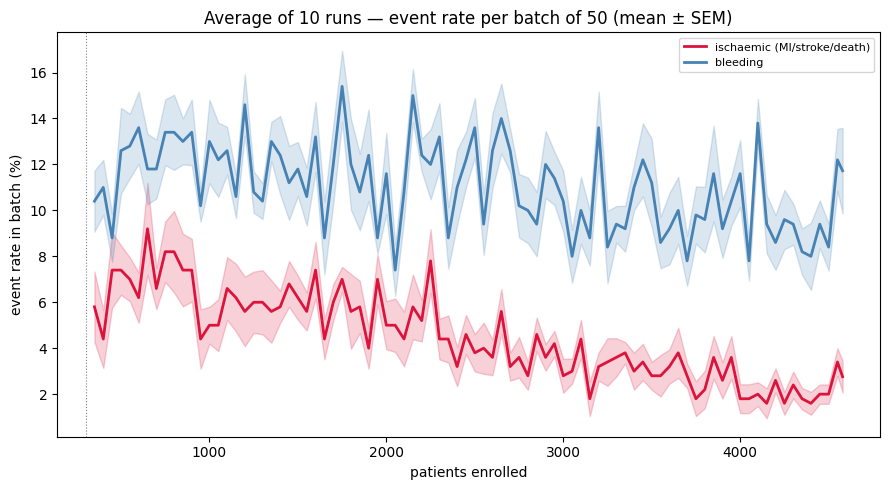

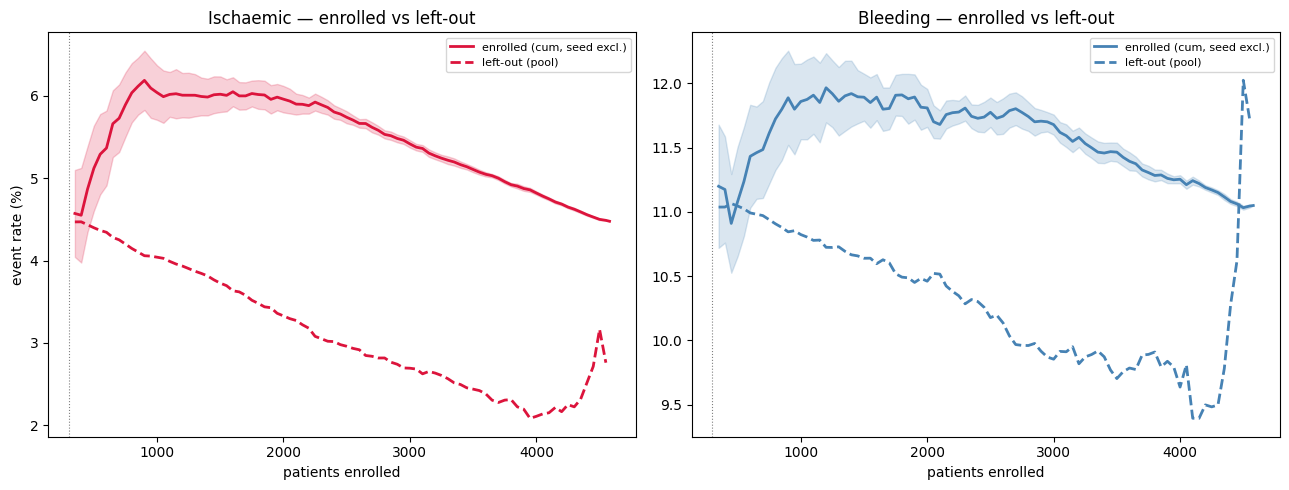

In [12]:
sem = lambda col: all_hist.groupby('step')[col].std() / np.sqrt(N_RUNS)

# -- figure 1: average per-batch event rate across runs
fig1, ax1 = plt.subplots(figsize=(9, 5))

for col, color, label in [('batch_isch', 'crimson', 'ischaemic (MI/stroke/death)'),
                          ('batch_bleed', 'steelblue', 'bleeding')]:
    m, s = summary[f'{col}_mean'], sem(col)
    ax1.plot(summary['n'], m * 100, color=color, lw=2, label=label)
    ax1.fill_between(summary['n'], (m - s) * 100, (m + s) * 100, color=color, alpha=.2)

ax1.axvline(N_SEED, color='k', lw=.8, ls=':', alpha=.5)
ax1.set(xlabel='patients enrolled', ylabel='event rate in batch (%)',
        title=f'Average of {N_RUNS} runs — event rate per batch of {BATCH_SIZE} (mean ± SEM)')
ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

# -- figure 2: cumulative enrolled vs left-out, split by endpoint
fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(13, 5))

m, s = summary['cum_isch_mean'], sem('cm_isch')
ax2.plot(summary['n'], m * 100, color='crimson', lw=2, label='enrolled (cum, seed excl.)')
ax2.fill_between(summary['n'], (m - s) * 100, (m + s) * 100, color='crimson', alpha=.2)
ax2.plot(summary['n'], summary['leftout_isch_mean'] * 100, color='crimson', lw=2, ls='--',
         label='left-out (pool)')
ax2.axvline(N_SEED, color='k', lw=.8, ls=':', alpha=.5)
ax2.set(xlabel='patients enrolled', ylabel='event rate (%)', title='Ischaemic — enrolled vs left-out')
ax2.legend(fontsize=8)

m, s = summary['cum_bleed_mean'], sem('cm_bleed')
ax3.plot(summary['n'], m * 100, color='steelblue', lw=2, label='enrolled (cum, seed excl.)')
ax3.fill_between(summary['n'], (m - s) * 100, (m + s) * 100, color='steelblue', alpha=.2)
ax3.plot(summary['n'], summary['leftout_bleed_mean'] * 100, color='steelblue', lw=2, ls='--',
         label='left-out (pool)')
ax3.axvline(N_SEED, color='k', lw=.8, ls=':', alpha=.5)
ax3.set(xlabel='patients enrolled', title='Bleeding — enrolled vs left-out')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Does the exploration bonus (`c > 0`) actually help the ranking?

The main run above (`c=0`) is pure exploitation: enrol whoever currently looks most like a
win-win, ignore how uncertain the model still is about them. The multi-run block (`c=1.0`)
turns exploration on. Now that `acquisition_score` z-scores the conflict term, `c=1.0` means
"explore about as much as exploit" (both terms ~unit scale) rather than the ~40x-mismatched
combination it would have been pre-fix.

Controlled A/B on the **same seed cohort** (`prep` from Phase 2), `c=0` vs `c=1`, read off
the AUTOC lower bound rather than the noisy observed rates: does spending some enrolment
slots on high-uncertainty patients (instead of pure top-conflict greedy) pay for itself in a
better ranking later? Bounded to `N_STOP_CMP` patients to keep this a quick probe, not a
full multi-seed study — the pairwise duel version of this same UCB1 rule showed real but
small enrichment from uncertainty-seeking, so temper expectations.

Stopping early: enrolled 2500 patients, which is >= N_STOP=2500.
c=0.0  final @ n=2400:  AUTOC lb=+0.0000  cm_isch=4.5%  cm_bleed=10.6%
Stopping early: enrolled 2500 patients, which is >= N_STOP=2500.
c=1.0  final @ n=2400:  AUTOC lb=+0.0000  cm_isch=4.5%  cm_bleed=10.6%


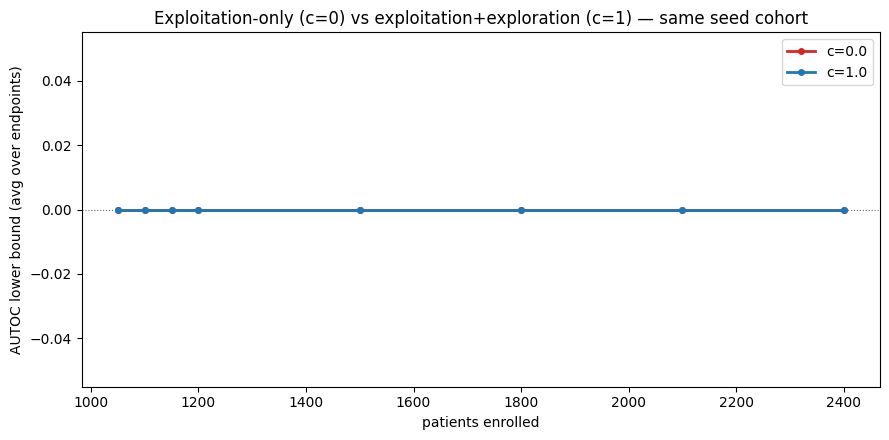

In [13]:
N_STOP_CMP = 2500   # bound runtime -- this is a quick probe, not a full multi-seed study

cmp_runs = {}
for c_val in [0.0, 1.0]:
    _, _, h = run_ranked_enrollment(prep, batch_size=BATCH_SIZE, c=c_val, refit_trials=0, verbose=False,
                                     N_STOP=N_STOP_CMP, temperature0=5.0, decay_rate=5.0,
                                     autoc_every=300)
    cmp_runs[c_val] = h.dropna(subset=['autoc_lb'])
    last = cmp_runs[c_val].iloc[-1]
    print(f"c={c_val:<3}  final @ n={int(last['n'])}:  AUTOC lb={last['autoc_lb']:+.4f}  "
          f"cm_isch={last['cm_isch']:.1%}  cm_bleed={last['cm_bleed']:.1%}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='k', lw=.8, ls=':', alpha=.6)
for c_val, color in zip(cmp_runs, ['tab:red', 'tab:blue']):
    ax.plot(cmp_runs[c_val]['n'], cmp_runs[c_val]['autoc_lb'], color=color, marker='o', ms=4, lw=2,
             label=f'c={c_val}')
ax.set(xlabel='patients enrolled', ylabel='AUTOC lower bound (avg over endpoints)',
       title='Exploitation-only (c=0) vs exploitation+exploration (c=1) — same seed cohort')
ax.legend()
plt.tight_layout()
plt.show()

## Net-benefit variant — ranking the pool by trade-off instead of win-win

`acquisition_score` above ranks the whole pool by `conflict` (`bleed + weighted_isch`, the
win-win score) plus an uncertainty bonus. This section adds `acquisition_score_net_benefit`,
the same UCB1-style combination reading `net_benefit_from_model` (`bleed - weighted_isch`, the
trade-off score) instead, and a duplicated `run_ranked_enrollment_net_benefit`. Same seed
(`prep`), same `batch_size`/`N_STOP`/tuning schedule as the win-win run above, so `hist` and
`hist_nb` are directly comparable batch by batch.

In [14]:
from online_learning_utils import net_benefit_from_model


def acquisition_score_net_benefit(net_benefit, uncertainty, idx, c=1.0):
    """Same UCB1-style combination as `acquisition_score` above, but exploitation reads the
    trade-off score (`net_benefit_from_model`, bleed - weighted_isch) instead of the win-win
    score (`conflict_from_model`, bleed + weighted_isch)."""
    idx   = np.asarray(idx)
    value = z(net_benefit['net_benefit']).to_numpy()[idx]
    bonus = np.clip(uncertainty['uncertainty'].to_numpy()[idx], 0, None)
    return value + c * bonus


def run_ranked_enrollment_net_benefit(prep, batch_size=100, c=1.0, refit_trials=0, verbose=True,
                                      N_STOP=None, temperature0=0.0, decay_rate=5.0, seed=SEED,
                                      autoc_every=None, autoc_cv=3, autoc_target_idx=None,
                                      tune_every=None, tune_trials=20):
    """Identical to `run_ranked_enrollment` above, but ranks every round by
    `acquisition_score_net_benefit` (trade-off score) instead of `acquisition_score`
    (win-win score)."""
    cf_params, nuisance_params = prep['cf_params'], prep['nuisance_params']
    enrolled = list(prep['seed_idx'])
    pool     = [i for i in range(N) if i not in set(enrolled)]
    rng      = np.random.default_rng(seed)
    next_autoc_at = autoc_every
    next_tune_at  = tune_every

    model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
    net_benefit = net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
    uncertainty = uncertainty_from_model(model)

    if N_STOP is not None and len(enrolled) >= N_STOP:
        print(f"Stopping early: enrolled {len(enrolled)} patients, which is >= N_STOP={N_STOP}.")
        return model, enrolled, pd.DataFrame([])

    hist = []
    while pool:
        if N_STOP is not None and len(enrolled) >= N_STOP:
            print(f"Stopping early: enrolled {len(enrolled)} patients, which is >= N_STOP={N_STOP}.")
            return model, enrolled, pd.DataFrame(hist)

        fraction_enrolled = len(enrolled) / N
        temperature = temperature0 * np.exp(-decay_rate * fraction_enrolled)

        score = acquisition_score_net_benefit(net_benefit, uncertainty, pool, c=c)
        batch = sample_batch(score, pool, batch_size, temperature=temperature, rng=rng)

        enrolled.extend(batch)
        pool = [p for p in pool if p not in set(batch)]

        y_batch    = y.loc[batch]
        y_enrolled = y[y.index.isin(enrolled)]
        y_left_out = y[~y.index.isin(enrolled)]

        def rates(yy):
            isch  = ((yy[ENDPOINTS['death']].to_numpy()  == 1) |
                     (yy[ENDPOINTS['mi']].to_numpy()     == 1) |
                     (yy[ENDPOINTS['stroke']].to_numpy() == 1))
            bleed = yy[ENDPOINTS['bleed']].to_numpy() == 1
            return isch.mean(), bleed.mean(), int(isch.sum()), int(bleed.sum())

        batch_isch, batch_bleed, batch_isch_n, batch_bleed_n = rates(y_batch)
        cm_isch,    cm_bleed,    cm_isch_n,    cm_bleed_n    = rates(y_enrolled)
        leftout_isch, leftout_bleed, leftout_isch_n, leftout_bleed_n = rates(y_left_out)

        autoc_lb = np.nan
        if autoc_every is not None and len(enrolled) >= next_autoc_at:
            autoc_lb = -model.score_cv_autoc(Xn.values[enrolled], Yv[enrolled], T[enrolled],
                                              cv=autoc_cv, z=1.0, target_idx=autoc_target_idx)
            next_autoc_at += autoc_every
            if verbose:
                print(f"         AUTOC lower bound (cv={autoc_cv}, target_idx={autoc_target_idx}): {autoc_lb:+.4f}")

        hist.append(dict(
            n=len(enrolled), batch_n=len(batch), temperature=temperature,
            batch_isch=batch_isch, batch_bleed=batch_bleed,
            cm_isch=cm_isch, cm_bleed=cm_bleed,
            leftout_n=len(y_left_out), leftout_isch=leftout_isch, leftout_bleed=leftout_bleed,
            cm_isch_n=cm_isch_n, cm_bleed_n=cm_bleed_n,
            leftout_isch_n=leftout_isch_n, leftout_bleed_n=leftout_bleed_n,
            autoc_lb=autoc_lb,
        ))

        if verbose:
            print(f"n={len(enrolled):4d} (+{len(batch)})  T={temperature:.3f}  "
                f"batch: isch={batch_isch_n} bleed={batch_bleed_n}  |  "
                f"cm: isch={cm_isch_n} bleed={cm_bleed_n}  |  "
                f"left-out n={len(y_left_out):4d}: isch={leftout_isch_n} bleed={leftout_bleed_n}")

        if refit_trials:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=SEED, n_trials=refit_trials)
        elif tune_every is not None and len(enrolled) >= next_tune_at:
            cf_params, nuisance_params, _ = tune_seed(enrolled, seed=seed, n_trials=tune_trials)
            next_tune_at += tune_every
            if verbose:
                print(f"         Re-tuned hyperparameters at n={len(enrolled)} (n_trials={tune_trials})")

        model       = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params, nuisance_params)
        net_benefit = net_benefit_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
        uncertainty = uncertainty_from_model(model)

    return model, enrolled, pd.DataFrame(hist)

In [15]:
model_nb, enrolled_nb, hist_nb = run_ranked_enrollment_net_benefit(
    prep, batch_size=BATCH_SIZE, c=0, refit_trials=0, verbose=True,
    N_STOP=N_STOP, temperature0=5.0, decay_rate=10.0,
    autoc_every=300, tune_every=300, tune_trials=30)

print(f"net-benefit run  seed={N_SEED}  final enrolled={len(enrolled_nb)}  batches={len(hist_nb)}")

         AUTOC lower bound (cv=3, target_idx=None): +0.0000
n=1050 (+50)  T=0.563  batch: isch=2 bleed=7  |  cm: isch=38 bleed=118  |  left-out n=3529: isch=167 bleed=388
         hyper-tuned: best CV score = -0.0000
         Re-tuned hyperparameters at n=1050 (n_trials=30)
         AUTOC lower bound (cv=3, target_idx=None): -0.0128
n=1100 (+50)  T=0.505  batch: isch=1 bleed=8  |  cm: isch=39 bleed=126  |  left-out n=3479: isch=166 bleed=380
         hyper-tuned: best CV score = -0.0000
         Re-tuned hyperparameters at n=1100 (n_trials=30)
         AUTOC lower bound (cv=3, target_idx=None): +0.0000
n=1150 (+50)  T=0.453  batch: isch=1 bleed=6  |  cm: isch=40 bleed=132  |  left-out n=3429: isch=165 bleed=374
         hyper-tuned: best CV score = -0.0000
         Re-tuned hyperparameters at n=1150 (n_trials=30)
         AUTOC lower bound (cv=3, target_idx=None): +0.0000
n=1200 (+50)  T=0.406  batch: isch=6 bleed=6  |  cm: isch=46 bleed=138  |  left-out n=3379: isch=159 bleed=368
    

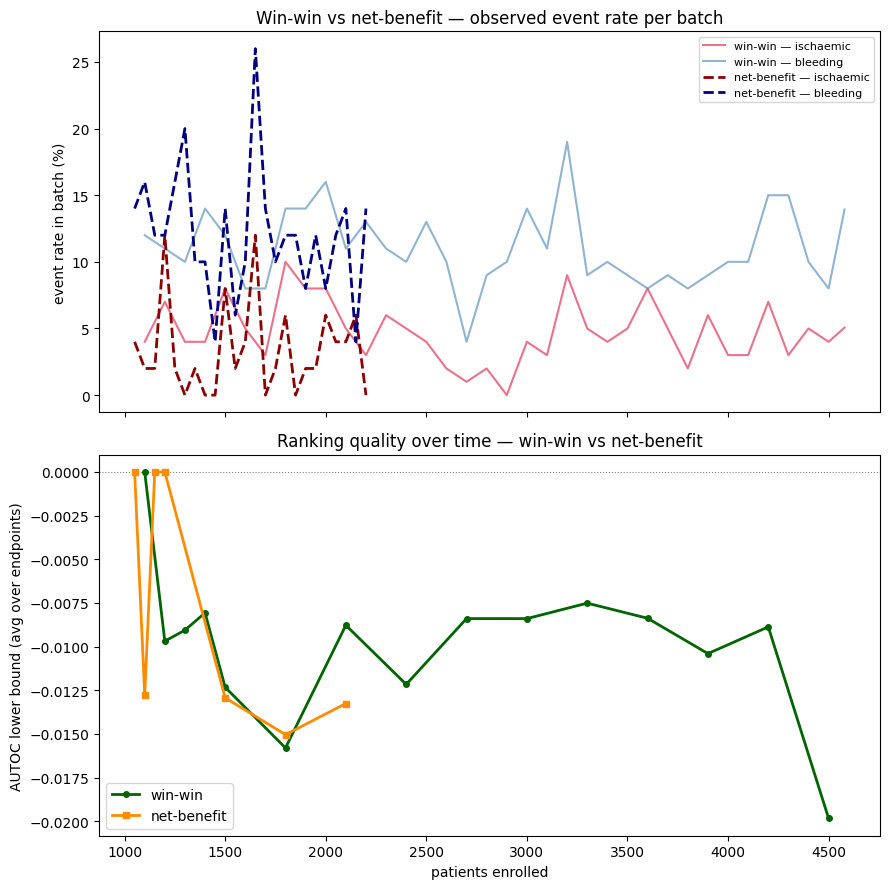

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

ax1.plot(hist['n'], hist['batch_isch'] * 100, color='crimson', lw=1.5, alpha=.6, label='win-win — ischaemic')
ax1.plot(hist['n'], hist['batch_bleed'] * 100, color='steelblue', lw=1.5, alpha=.6, label='win-win — bleeding')
ax1.plot(hist_nb['n'], hist_nb['batch_isch'] * 100, color='darkred', lw=2, ls='--', label='net-benefit — ischaemic')
ax1.plot(hist_nb['n'], hist_nb['batch_bleed'] * 100, color='navy', lw=2, ls='--', label='net-benefit — bleeding')
ax1.set(ylabel='event rate in batch (%)', title='Win-win vs net-benefit — observed event rate per batch')
ax1.legend(fontsize=8)

autoc_win = hist.dropna(subset=['autoc_lb'])
autoc_nb  = hist_nb.dropna(subset=['autoc_lb'])
ax2.axhline(0, color='k', lw=.8, ls=':', alpha=.5)
ax2.plot(autoc_win['n'], autoc_win['autoc_lb'], color='darkgreen', marker='o', ms=4, lw=2, label='win-win')
ax2.plot(autoc_nb['n'], autoc_nb['autoc_lb'], color='darkorange', marker='s', ms=4, lw=2, label='net-benefit')
ax2.set(xlabel='patients enrolled', ylabel='AUTOC lower bound (avg over endpoints)',
        title='Ranking quality over time — win-win vs net-benefit')
ax2.legend()

plt.tight_layout()
plt.show()

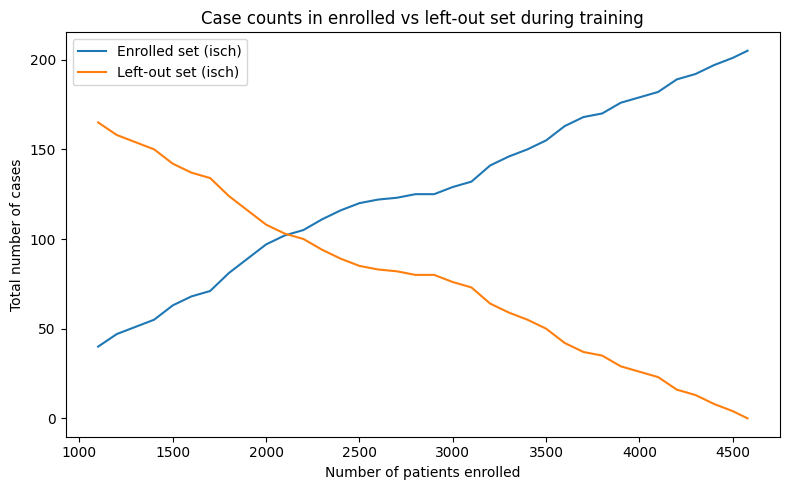

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(hist['n'], hist['cm_isch_n'],
        label='Enrolled set (isch)', color='tab:blue')
ax.plot(hist['n'], hist['leftout_isch_n'],
        label='Left-out set (isch)', color='tab:orange')

ax.set_xlabel('Number of patients enrolled')
ax.set_ylabel('Total number of cases')
ax.set_title('Case counts in enrolled vs left-out set during training')
ax.legend()
plt.tight_layout()
plt.show()